# 📐 Statistical Analysis — Demo Notebook
### Auto-MPG Dataset (Part 2 of 3)

**What we cover in this notebook:**

| Section | Topic |
|---|---|
| 1 | Key statistical concepts & hypothesis testing framework |
| 2 | Setup & data loading |
| 3 | Chi-square & Fisher's exact tests (categorical independence) |
| 4 | Normality tests — visual & statistical |
| 5 | Power transformation |
| 6 | Correlation tests (Pearson, Spearman, Kendall) |
| 7 | Parametric tests (t-test, ANOVA) |
| 8 | Non-parametric tests (Mann-Whitney U, Kruskal-Wallis) |
| 9 | Categorical vs Continuous (ANOVA / chi2 feature selection) |

> **α = 0.05** is used as the significance level throughout.


## 1. Key Statistical Concepts

| Term | Definition |
|---|---|
| **Population** | The complete set of all possible observations |
| **Sample** | A subset drawn from the population |
| **Parameter** | A property of the population (e.g., true mean μ) |
| **Estimate** | A sample-based approximation of a parameter (e.g., x̄) |
| **H₀ (Null)** | No significant difference / no effect |
| **H₁ (Alternate)** | Significant difference / effect exists |
| **p-value** | Probability of observing the data *if H₀ is true* |
| **α (alpha)** | Significance threshold — we use **0.05** |
| **Parametric** | Assumes a distribution (e.g., Gaussian) |
| **Non-parametric** | Distribution-free |

### Decision Rule
```
p-value ≤ α  →  Reject H₀  (significant result)
p-value  > α  →  Fail to reject H₀
```


## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, chi2_contingency, fisher_exact,
                         pearsonr, spearmanr, kendalltau,
                         ttest_ind, mannwhitneyu, kruskal, f_oneway)
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import chi2, f_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

ALPHA = 0.05
print("Libraries loaded ✓  |  ALPHA =", ALPHA)


Libraries loaded ✓  |  ALPHA = 0.05


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Type fixes
df['cylinders']  = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')
df['origin']     = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})
df['car_name']   = df['car_name'].str.strip().str.lower()

# Feature engineering
df['mpg_level']    = pd.cut(df['mpg'], bins=[0,17,29,df['mpg'].max()+1],
                             labels=['low','medium','high'], right=False)
df['car_company']  = df['car_name'].str.split().str[0]

cat_cols = ['cylinders','origin','model_year','mpg_level']
num_cols = ['mpg','displacement','horsepower','weight','acceleration']

print("Dataset ready — shape:", df.shape)
df.head()


Dataset ready — shape: (392, 11)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_level,car_company
0,18.0,8,307.0,130.0,3504.0,12.0,70,usa,chevrolet chevelle malibu,medium,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,usa,buick skylark 320,low,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,usa,plymouth satellite,medium,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,usa,amc rebel sst,low,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,usa,ford torino,medium,ford


## 3. Tests for Independence — Categorical Variables

### Pearson's Chi-Square Test
- Tests whether two categorical variables are **independent**
- **H₀:** Variable A and Variable B are independent
- Assumption: all expected cell counts ≥ 5
- If >20% of cells have expected count < 5 → use **Fisher's Exact Test**


In [3]:
# ── Check expected cell counts for every pair ────────────────────────────
from itertools import combinations

pairs = list(combinations(['cylinders','origin','model_year','mpg_level'], 2))

print(f"{'Pair':<35} {'Min Expected':>14}  {'<5 cells %':>12}  {'Use Fisher?':>12}")
print("-" * 80)
for a, b in pairs:
    ct = pd.crosstab(df[a], df[b])
    chi2_stat, p, dof, expected = chi2_contingency(ct)
    pct_low = (expected < 5).mean() * 100
    use_fisher = "YES ⚠️" if pct_low > 20 else "No"
    print(f"{a} × {b:<25} {expected.min():>14.2f}  {pct_low:>11.1f}%  {use_fisher:>12}")


Pair                                  Min Expected    <5 cells %   Use Fisher?
--------------------------------------------------------------------------------
cylinders × origin                              0.52         40.0%        YES ⚠️
cylinders × model_year                          0.20         40.0%        YES ⚠️
cylinders × mpg_level                           0.70         40.0%        YES ⚠️
origin × model_year                          4.51         15.4%            No
origin × mpg_level                          15.96          0.0%            No
model_year × mpg_level                           6.10          0.0%            No


In [4]:
# ── Chi-Square: origin × model_year (most cells ≥ 5) ────────────────────
ct_orig_year = pd.crosstab(df['origin'], df['model_year'])
chi2_stat, p_val, dof, expected = chi2_contingency(ct_orig_year)

print("=== Chi-Square Test: origin × model_year ===")
print(f"  χ² statistic : {chi2_stat:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value      : {p_val:.4f}")
if p_val <= ALPHA:
    print(f"  → p ≤ {ALPHA}: REJECT H₀ — origin and model_year are NOT independent")
else:
    print(f"  → p > {ALPHA}: FAIL to reject H₀ — origin and model_year are independent")


=== Chi-Square Test: origin × model_year ===
  χ² statistic : 47.3004
  Degrees of freedom: 24
  p-value      : 0.0031
  → p ≤ 0.05: REJECT H₀ — origin and model_year are NOT independent


In [7]:
# 1. Check if values are strings or ints (Cylinders are often ints in this dataset)
# Let's use a flexible filter
target_cyls = [4, 8] 
target_origins = ['usa', 'japan']

sub = df[df['cylinders'].astype(int).isin(target_cyls) & df['origin'].isin(target_origins)]

# 2. Check if the subset is empty
if sub.empty:
    print("Error: No data found for the selected criteria!")
else:
    # 3. Create the crosstab
    ct_2x2 = pd.crosstab(sub['cylinders'], sub['origin'])
    
    # Check if we actually have a 2x2 shape
    if ct_2x2.shape == (2, 2):
        print("Contingency table:")
        print(ct_2x2)
        
        odds_ratio, p_fisher = fisher_exact(ct_2x2)
        print(f"\nFisher's Exact Test p-value: {p_fisher:.6f}")
    else:
        print(f"Cannot run Fisher's: Table shape is {ct_2x2.shape}. Is there data for all 4 cells?")
        print(ct_2x2)

Contingency table:
origin     japan  usa
cylinders            
4             69   69
8              0  103

Fisher's Exact Test p-value: 0.000000


In [8]:
# ── sklearn chi2: which categorical features relate to mpg_level? ────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['mpg_level'])

# Encode categorical features as numeric codes
X_cat = df[['cylinders','origin','model_year']].apply(
    lambda col: le.fit_transform(col.astype(str)))

chi2_scores, chi2_pvals = chi2(X_cat, y)

results = pd.DataFrame({'Feature': X_cat.columns,
                        'Chi2 Score': chi2_scores,
                        'p-value': chi2_pvals})
print("Chi2 dependency with mpg_level:")
print(results.sort_values('Chi2 Score', ascending=False).to_string(index=False))


Chi2 dependency with mpg_level:
   Feature  Chi2 Score      p-value
model_year  263.918465 4.907196e-58
 cylinders  180.050574 7.989410e-40
    origin   31.263174 1.626627e-07


## 4. Normality Testing

### Why it matters
Many parametric tests (t-test, Pearson correlation, ANOVA) assume **Gaussian-distributed** data.
We test normality two ways:
1. **Visual** — Histogram + KDE, Q-Q plot
2. **Statistical** — Shapiro-Wilk test

**H₀: Data is drawn from a normal distribution**


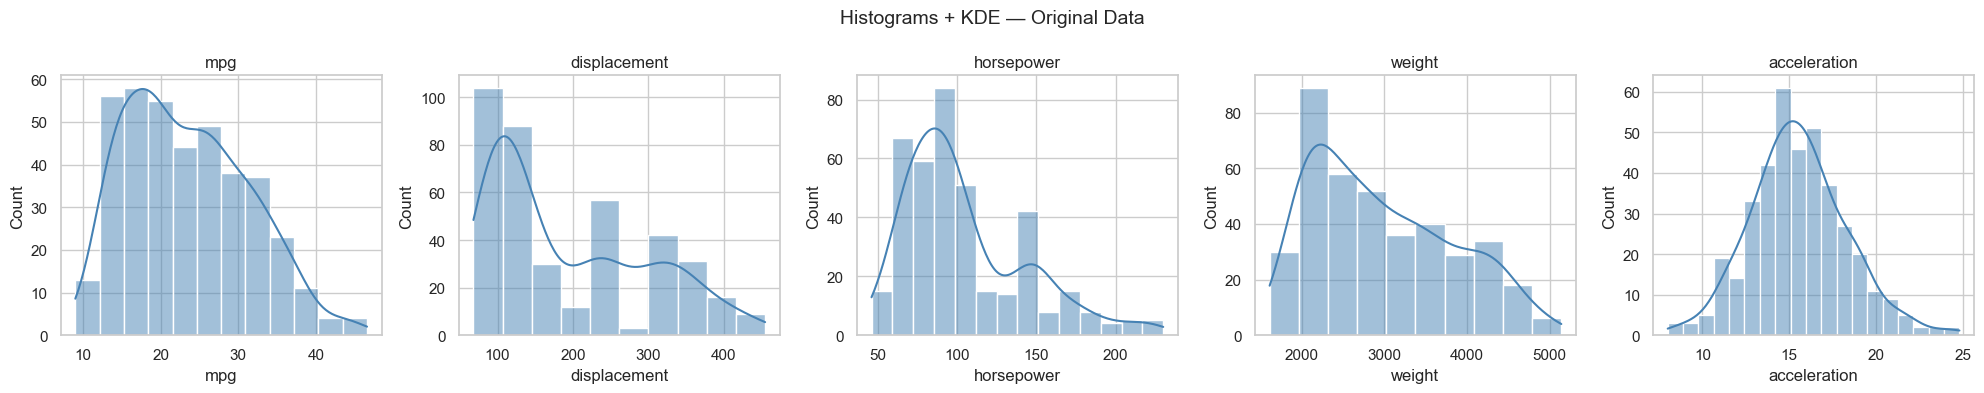

Observation: acceleration looks Gaussian; others are skewed.


In [9]:
# ── Visual: Histogram + KDE ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Histograms + KDE — Original Data', fontsize=14)
plt.tight_layout(); plt.show()
print("Observation: acceleration looks Gaussian; others are skewed.")


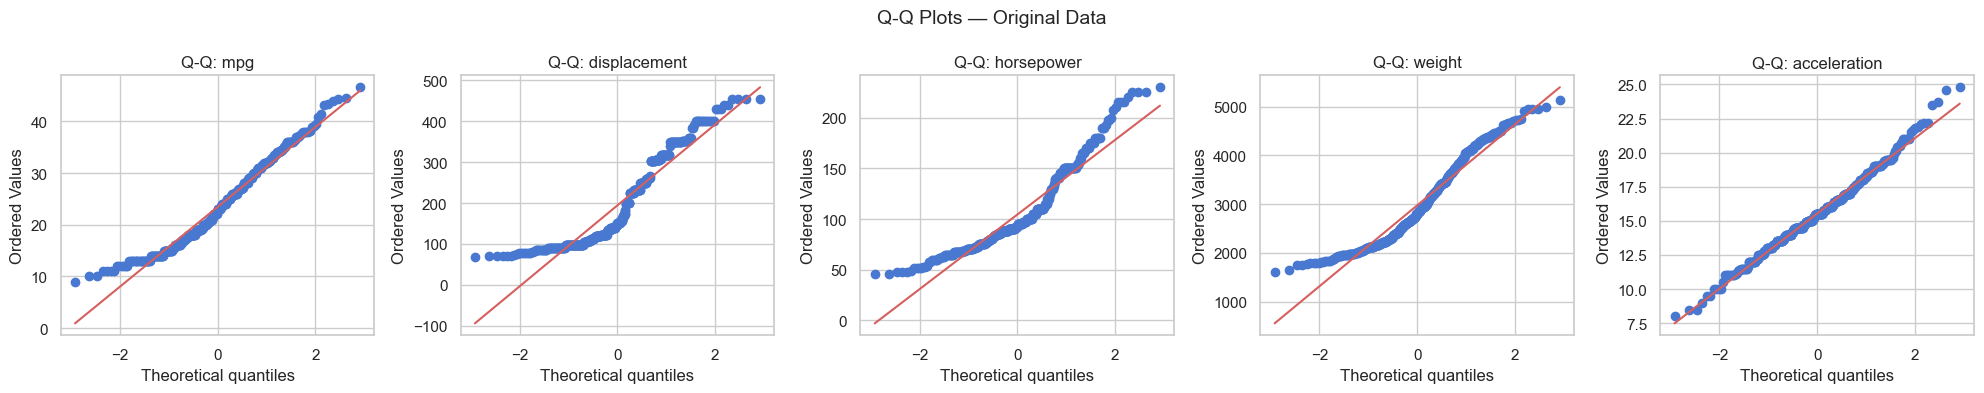

Points near the diagonal line → closer to Gaussian.


In [10]:
# ── Visual: Q-Q plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}')
plt.suptitle('Q-Q Plots — Original Data', fontsize=14)
plt.tight_layout(); plt.show()
print("Points near the diagonal line → closer to Gaussian.")


In [11]:
# ── Shapiro-Wilk normality test ───────────────────────────────────────────
print("=== Shapiro-Wilk Normality Test (H₀: data is normal) ===")
print(f"{'Feature':<15} {'Statistic':>10} {'p-value':>10} {'Normal?':>10}")
print("-" * 50)
for col in num_cols:
    stat, p = shapiro(df[col])
    result = "YES" if p > ALPHA else "NO ✗"
    print(f"{col:<15} {stat:>10.4f} {p:>10.4f} {result:>10}")


=== Shapiro-Wilk Normality Test (H₀: data is normal) ===
Feature          Statistic    p-value    Normal?
--------------------------------------------------
mpg                 0.9672     0.0000       NO ✗
displacement        0.8818     0.0000       NO ✗
horsepower          0.9041     0.0000       NO ✗
weight              0.9415     0.0000       NO ✗
acceleration        0.9919     0.0305       NO ✗


## 5. Power Transformation
`PowerTransformer` (Yeo-Johnson) makes skewed distributions more Gaussian-like
by applying monotonic transformations (log, square-root, etc.).
Useful before applying parametric tests.


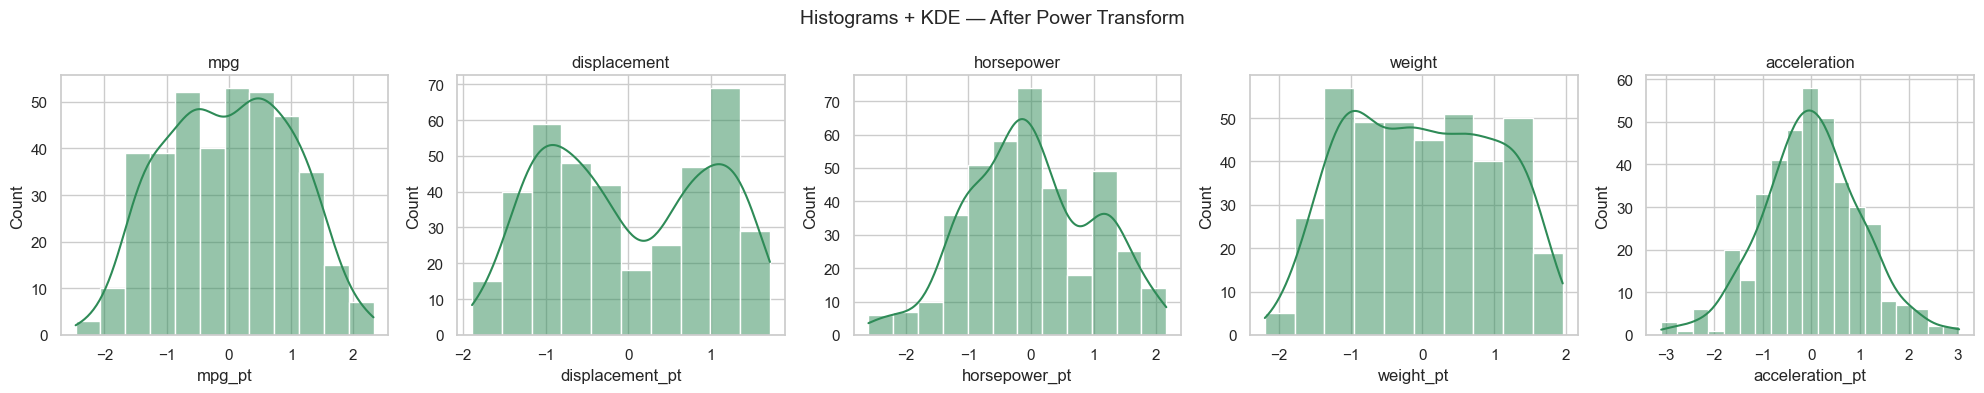

In [12]:
# ── Apply Power Transform ────────────────────────────────────────────────
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df_transformed = pd.DataFrame(
    pt.fit_transform(df[num_cols]),
    columns=[c + '_pt' for c in num_cols]
)

# Histograms after transform
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, df_transformed.columns):
    sns.histplot(df_transformed[col], kde=True, ax=ax, color='seagreen')
    ax.set_title(col.replace('_pt',''))
plt.suptitle('Histograms + KDE — After Power Transform', fontsize=14)
plt.tight_layout(); plt.show()


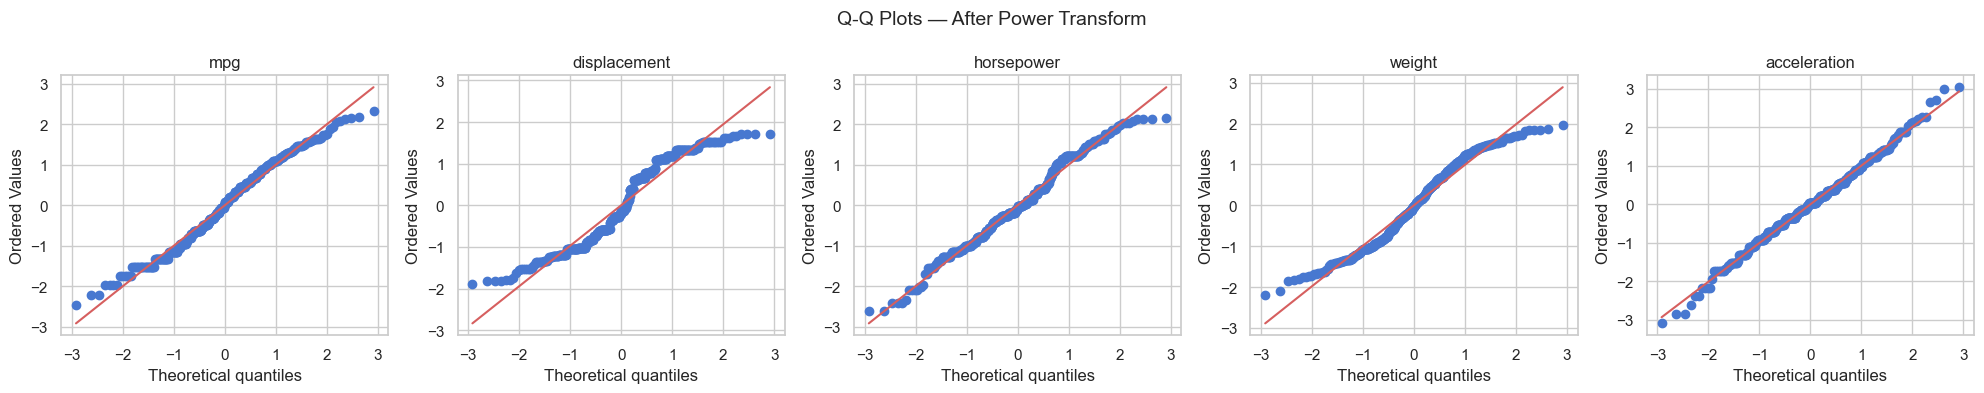

In [13]:
# ── Q-Q plots after transform ────────────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, df_transformed.columns):
    stats.probplot(df_transformed[col], dist='norm', plot=ax)
    ax.set_title(col.replace('_pt',''))
plt.suptitle('Q-Q Plots — After Power Transform', fontsize=14)
plt.tight_layout(); plt.show()


In [14]:
# ── Shapiro-Wilk after transform ─────────────────────────────────────────
print("=== Shapiro-Wilk after Power Transform ===")
print(f"{'Feature':<20} {'p-value':>10} {'Normal?':>10}")
print("-" * 43)
for col in df_transformed.columns:
    stat, p = shapiro(df_transformed[col])
    result = "YES ✓" if p > ALPHA else "NO ✗"
    print(f"{col:<20} {p:>10.4f} {result:>10}")


=== Shapiro-Wilk after Power Transform ===
Feature                 p-value    Normal?
-------------------------------------------
mpg_pt                   0.0001       NO ✗
displacement_pt          0.0000       NO ✗
horsepower_pt            0.0004       NO ✗
weight_pt                0.0000       NO ✗
acceleration_pt          0.3865      YES ✓


## 6. Correlation Tests

| Method | Type | Assumption |
|---|---|---|
| **Pearson** | Linear | Both variables Gaussian, linear relationship |
| **Spearman** | Rank / monotonic | Distribution-free |
| **Kendall** | Rank / concordance | Distribution-free |

**H₀: The two variables are uncorrelated (α = 0.05)**

We use **Spearman** as the default because not all variables are Gaussian.


In [15]:
# ── Pearson correlation of mpg with other numerics ───────────────────────
print("=== Pearson Correlation with mpg ===")
print(f"{'Feature':<15} {'r':>8} {'p-value':>10} {'Reject H₀?':>12}")
print("-"*50)
for col in [c for c in num_cols if c != 'mpg']:
    r, p = pearsonr(df['mpg'], df[col])
    print(f"{col:<15} {r:>8.4f} {p:>10.4f} {'YES' if p<=ALPHA else 'NO':>12}")


=== Pearson Correlation with mpg ===
Feature                r    p-value   Reject H₀?
--------------------------------------------------
displacement     -0.8051     0.0000          YES
horsepower       -0.7784     0.0000          YES
weight           -0.8322     0.0000          YES
acceleration      0.4233     0.0000          YES


In [16]:
# ── Spearman correlation (preferred — distribution-free) ─────────────────
print("=== Spearman Rank Correlation with mpg ===")
print(f"{'Feature':<15} {'ρ':>8} {'p-value':>10} {'Reject H₀?':>12} {'Effect':>8}")
print("-"*55)
for col in [c for c in num_cols if c != 'mpg']:
    rho, p = spearmanr(df['mpg'], df[col])
    effect = 'Large' if abs(rho)>=0.5 else ('Medium' if abs(rho)>=0.3 else 'Small')
    print(f"{col:<15} {rho:>8.4f} {p:>10.4f} {'YES' if p<=ALPHA else 'NO':>12} {effect:>8}")


=== Spearman Rank Correlation with mpg ===
Feature                ρ    p-value   Reject H₀?   Effect
-------------------------------------------------------
displacement     -0.8552     0.0000          YES    Large
horsepower       -0.8536     0.0000          YES    Large
weight           -0.8756     0.0000          YES    Large
acceleration      0.4415     0.0000          YES   Medium


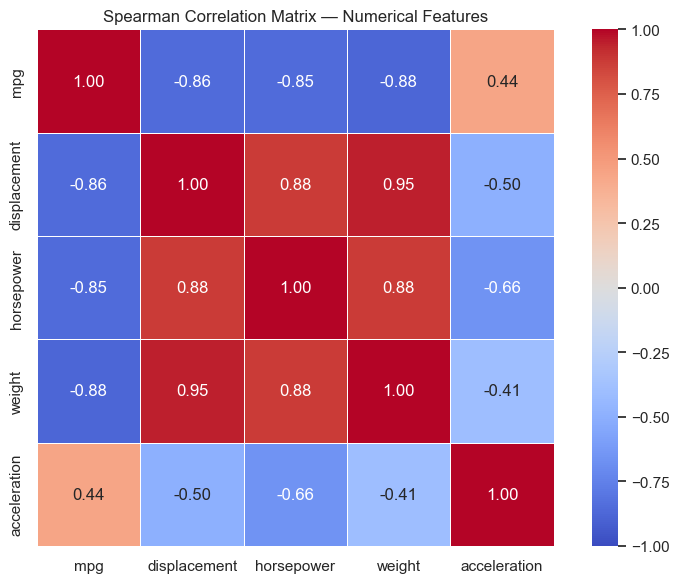

In [17]:
# ── Full Spearman correlation matrix heatmap ─────────────────────────────
corr_matrix = df[num_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix — Numerical Features')
plt.tight_layout(); plt.show()


In [18]:
# ── Kendall's tau ─────────────────────────────────────────────────────────
print("=== Kendall's Tau with mpg ===")
for col in [c for c in num_cols if c != 'mpg']:
    tau, p = kendalltau(df['mpg'], df[col])
    print(f"  {col:<15}: τ = {tau:+.4f}  p = {p:.4f}  {'REJECT H₀' if p<=ALPHA else 'fail'}")


=== Kendall's Tau with mpg ===
  displacement   : τ = -0.6786  p = 0.0000  REJECT H₀
  horsepower     : τ = -0.6792  p = 0.0000  REJECT H₀
  weight         : τ = -0.6942  p = 0.0000  REJECT H₀
  acceleration   : τ = +0.3031  p = 0.0000  REJECT H₀


## 7. Parametric Tests (t-test & ANOVA)

Use when samples are **normally distributed**.

- **Student's t-test** — compare means of 2 independent groups
- **ANOVA** — compare means of 3+ independent groups

**H₀: The sample means are equal across groups**


In [19]:
# ── t-test: acceleration in Japan vs USA ─────────────────────────────────
acc_japan = df[df['origin']=='japan']['acceleration']
acc_usa   = df[df['origin']=='usa']['acceleration']

# Verify normality first
_, p_j = shapiro(acc_japan)
_, p_u = shapiro(acc_usa)
print(f"Normality check — Japan: p={p_j:.4f}  USA: p={p_u:.4f}")
print(f"Both normal? {'YES' if p_j>ALPHA and p_u>ALPHA else 'NO — consider non-parametric'}")

# Check variance equality (Levene's test)
lev_stat, lev_p = stats.levene(acc_japan, acc_usa)
equal_var = lev_p > ALPHA
print(f"\nLevene's test for equal variance: p={lev_p:.4f} → equal_var={equal_var}")

# t-test
t_stat, p_ttest = ttest_ind(acc_japan, acc_usa, equal_var=equal_var)
print(f"\n=== t-test: acceleration — Japan vs USA ===")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_ttest:.4f}")
if p_ttest <= ALPHA:
    print(f"  → REJECT H₀: means are significantly different")
else:
    print(f"  → FAIL to reject H₀: no significant difference in means")


Normality check — Japan: p=0.5289  USA: p=0.6569
Both normal? YES

Levene's test for equal variance: p=0.0038 → equal_var=False

=== t-test: acceleration — Japan vs USA ===
  t-statistic : 4.2070
  p-value     : 0.0000
  → REJECT H₀: means are significantly different


In [17]:
# ── ANOVA: mpg across all 3 origins ──────────────────────────────────────
groups = [df[df['origin']==o]['mpg'].values for o in ['usa','europe','japan']]

# Normality check per group
print("Normality per group:")
for o, g in zip(['usa','europe','japan'], groups):
    _, p_n = shapiro(g)
    print(f"  {o}: p={p_n:.4f} {'✓' if p_n>ALPHA else '✗'}")

f_stat, p_anova = f_oneway(*groups)
print(f"\n=== One-Way ANOVA: mpg across origins ===")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.4f}")
if p_anova <= ALPHA:
    print("  → REJECT H₀: at least one origin has a different mean mpg")
else:
    print("  → FAIL to reject H₀")


Normality per group:
  usa: p=0.0000 ✗
  europe: p=0.0054 ✗
  japan: p=0.2420 ✓

=== One-Way ANOVA: mpg across origins ===
  F-statistic : 96.6015
  p-value     : 0.0000
  → REJECT H₀: at least one origin has a different mean mpg


## 8. Non-Parametric Tests

Use when samples are **not** normally distributed.

- **Mann-Whitney U** — non-parametric equivalent of t-test (2 groups)
- **Kruskal-Wallis H** — non-parametric equivalent of ANOVA (3+ groups)

**H₀: Sample distributions are equal**


In [20]:
# ── Mann-Whitney U: horsepower Japan vs USA ───────────────────────────────
hp_japan = df[df['origin']=='japan']['horsepower']
hp_usa   = df[df['origin']=='usa']['horsepower']

# Normality check
_, p_j = shapiro(hp_japan)
_, p_u = shapiro(hp_usa)
print(f"Normality check — Japan: p={p_j:.4f}  USA: p={p_u:.4f}")
print(f"Parametric appropriate? {'YES' if p_j>ALPHA and p_u>ALPHA else 'NO → use non-parametric'}")

u_stat, p_mw = mannwhitneyu(hp_japan, hp_usa, alternative='two-sided')
print(f"\n=== Mann-Whitney U: horsepower — Japan vs USA ===")
print(f"  U-statistic : {u_stat:.2f}")
print(f"  p-value     : {p_mw:.6f}")
if p_mw <= ALPHA:
    print("  → REJECT H₀: distributions significantly differ")
else:
    print("  → FAIL to reject H₀")


Normality check — Japan: p=0.0002  USA: p=0.0000
Parametric appropriate? NO → use non-parametric

=== Mann-Whitney U: horsepower — Japan vs USA ===
  U-statistic : 3638.00
  p-value     : 0.000000
  → REJECT H₀: distributions significantly differ


In [19]:
# ── Kruskal-Wallis: horsepower across all 3 origins ──────────────────────
groups_hp = [df[df['origin']==o]['horsepower'].values for o in ['usa','europe','japan']]

h_stat, p_kw = kruskal(*groups_hp)
print("=== Kruskal-Wallis: horsepower across all origins ===")
print(f"  H-statistic : {h_stat:.4f}")
print(f"  p-value     : {p_kw:.6f}")
if p_kw <= ALPHA:
    print("  → REJECT H₀: at least one region has different horsepower distribution")
else:
    print("  → FAIL to reject H₀")


=== Kruskal-Wallis: horsepower across all origins ===
  H-statistic : 105.5948
  p-value     : 0.000000
  → REJECT H₀: at least one region has different horsepower distribution


In [21]:
# ── Kruskal-Wallis: mpg across model_years ───────────────────────────────
year_groups = [df[df['model_year']==y]['mpg'].values
               for y in df['model_year'].cat.categories]

h_stat2, p_kw2 = kruskal(*year_groups)
print("=== Kruskal-Wallis: mpg across model_years ===")
print(f"  H-statistic : {h_stat2:.4f}  |  p-value: {p_kw2:.6f}")
print(f"  → {'REJECT' if p_kw2<=ALPHA else 'FAIL TO REJECT'} H₀")


=== Kruskal-Wallis: mpg across model_years ===
  H-statistic : 159.7251  |  p-value: 0.000000
  → REJECT H₀


In [22]:
# ── Mann-Whitney: acceleration — high vs medium mpg_level ────────────────
acc_high   = df[df['mpg_level']=='high']['acceleration']
acc_medium = df[df['mpg_level']=='medium']['acceleration']

u2, p2 = mannwhitneyu(acc_high, acc_medium, alternative='two-sided')
print("=== Mann-Whitney U: acceleration — high vs medium mpg_level ===")
print(f"  p-value: {p2:.4f}  → {'REJECT' if p2<=ALPHA else 'FAIL TO REJECT'} H₀")


=== Mann-Whitney U: acceleration — high vs medium mpg_level ===
  p-value: 0.0556  → FAIL TO REJECT H₀


## 9. Categorical vs Continuous — Feature Selection

Using **sklearn's** `f_classif` (ANOVA F-test) to measure how much each
numerical feature relates to `mpg_level`.


=== ANOVA F-test: Numerical features vs mpg_level ===
     Feature    F-Score       p-value
         mpg 898.850336 1.432752e-146
      weight 471.074120 1.211040e-104
displacement 438.585521 2.043761e-100
  horsepower 413.684546  5.011662e-97
acceleration  56.158190  3.744846e-22


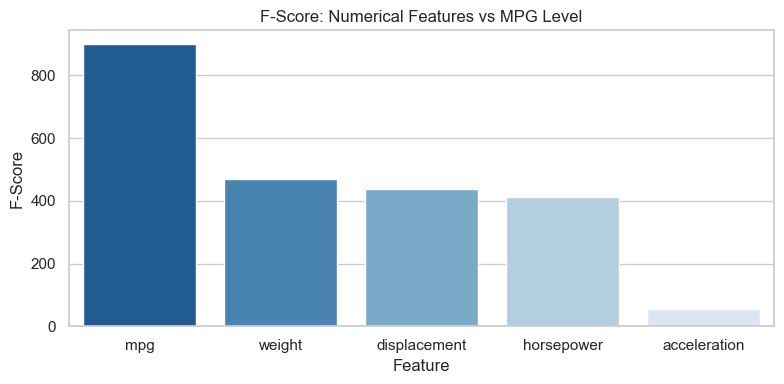

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['mpg_level'])
X_num = df[num_cols]

f_scores, f_pvals = f_classif(X_num, y)

fs_df = pd.DataFrame({'Feature': num_cols,
                       'F-Score': f_scores,
                       'p-value': f_pvals}
                     ).sort_values('F-Score', ascending=False)

print("=== ANOVA F-test: Numerical features vs mpg_level ===")
print(fs_df.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=fs_df, x='Feature', y='F-Score', palette='Blues_r')
plt.title('F-Score: Numerical Features vs MPG Level')
plt.tight_layout(); plt.show()


## 10. Summary of Key Findings

| Test | Variables | Result |
|---|---|---|
| Chi-Square | origin × model_year | **NOT independent** (p < 0.05) |
| Fisher's Exact | 4-cyl vs 8-cyl (usa vs japan) | **Significant association** |
| Shapiro-Wilk (raw) | acceleration | Close to normal |
| Shapiro-Wilk (transformed) | mpg, displacement | Become more normal |
| Spearman | mpg × weight | **r = −0.83** (large negative) |
| Spearman | mpg × acceleration | Moderate positive |
| t-test | acceleration: japan vs usa | **Different means** |
| ANOVA | mpg across origins | **Significantly different** |
| Kruskal-Wallis | horsepower across origins | **Distributions differ** |
| ANOVA F-score | weight → mpg_level | **Strongest predictor** |

> All findings are consistent with Part 1 (EDA) observations.
